In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [58]:
print("=" * 60)
print("EDA")
print("=" * 60)

EDA


In [59]:
df = pd.read_csv("data/used_cars.csv")
print(df.shape)
print(f"Dataset have {df.shape[0]} rows and {df.shape[1]} colums")
for col in df.columns:
    print(f"Col: {col}")
    
print(df.info())
print(df.describe().round(2))

(1500, 10)
Dataset have 1500 rows and 10 colums
Col: brand
Col: model_year
Col: mileage_km
Col: engine_size_L
Col: fuel_type
Col: transmission
Col: num_owners
Col: accident_history
Col: service_history
Col: price_usd
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             1500 non-null   object 
 1   model_year        1500 non-null   int64  
 2   mileage_km        1442 non-null   float64
 3   engine_size_L     1432 non-null   float64
 4   fuel_type         1500 non-null   object 
 5   transmission      1500 non-null   object 
 6   num_owners        1500 non-null   int64  
 7   accident_history  1500 non-null   int64  
 8   service_history   1189 non-null   object 
 9   price_usd         1500 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 117.3+ KB
None
       model_year  mileage_km  engine_size_

In [60]:
print("5 first rows")
print(df.head())

5 first rows
     brand  model_year  mileage_km  engine_size_L fuel_type transmission  \
0     Ford        2021     41658.0            2.0    Diesel    Automatic   
1      Kia        2013    151762.0            3.0    Petrol    Automatic   
2    Mazda        2006    200465.0            2.0    Petrol       Manual   
3  Hyundai        2022     38038.0            1.2    Petrol    Automatic   
4    Honda        2013         NaN            1.6    Petrol    Automatic   

   num_owners  accident_history service_history  price_usd  
0           1                 1            Full      30700  
1           3                 0             NaN      19600  
2           2                 0         Partial      14600  
3           2                 0         Partial      31700  
4           2                 0             NaN      26200  


In [61]:
print("Check missing value")
print(df.isnull().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"Column have missing value {col} with {round((df[col].isnull().sum() / len(df) * 100),2)} %")

Check missing value
brand                 0
model_year            0
mileage_km           58
engine_size_L        68
fuel_type             0
transmission          0
num_owners            0
accident_history      0
service_history     311
price_usd             0
dtype: int64
Column have missing value mileage_km with 3.87 %
Column have missing value engine_size_L with 4.53 %
Column have missing value service_history with 20.73 %


In [62]:
print("Check duplicate value")
print(df.duplicated().sum())

Check duplicate value
0


In [63]:
numerics_columns = df.select_dtypes(['float64', 'int64']).columns

for col in numerics_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1 
    
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    
    if outliers.sum() > 0:
        print(f"Outliers in {col}: {outliers.sum()}")
    
    # median = df[col].median()
    
    # df[col].apply(
    #     lambda x: median if (x < lower_bound or x > upper_bound) else x 
    # )
    
    df[col] = df[col].clip(lower= lower_bound, upper=upper_bound)

Outliers in mileage_km: 10
Outliers in engine_size_L: 134
Outliers in num_owners: 86


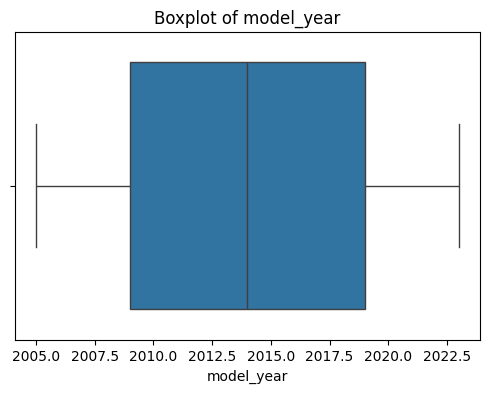

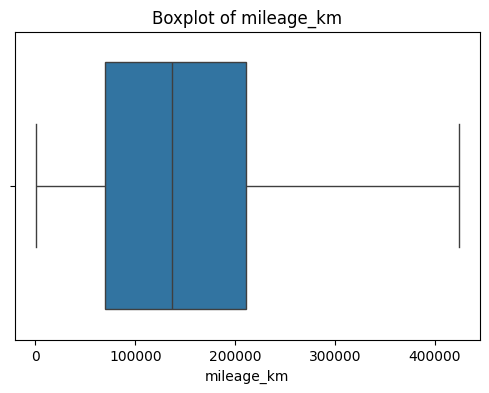

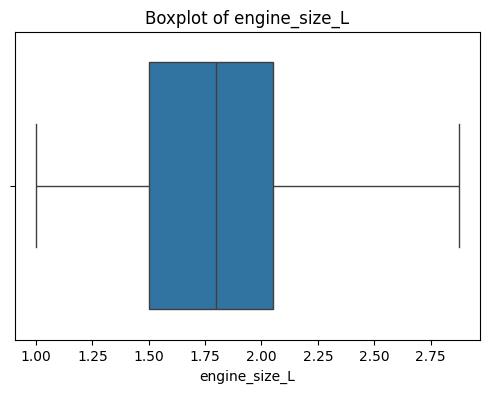

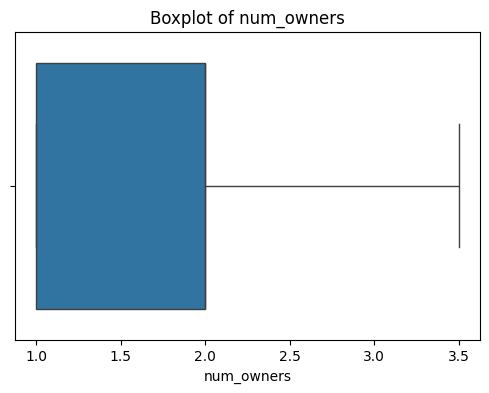

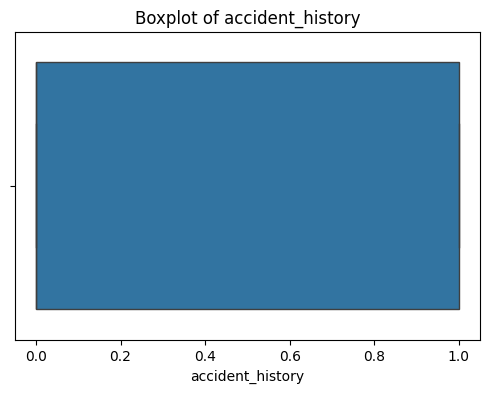

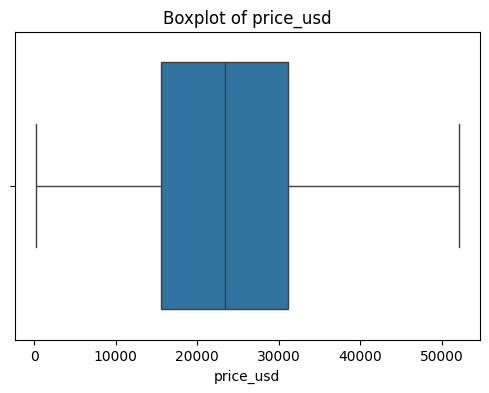

In [64]:
for col in numerics_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    

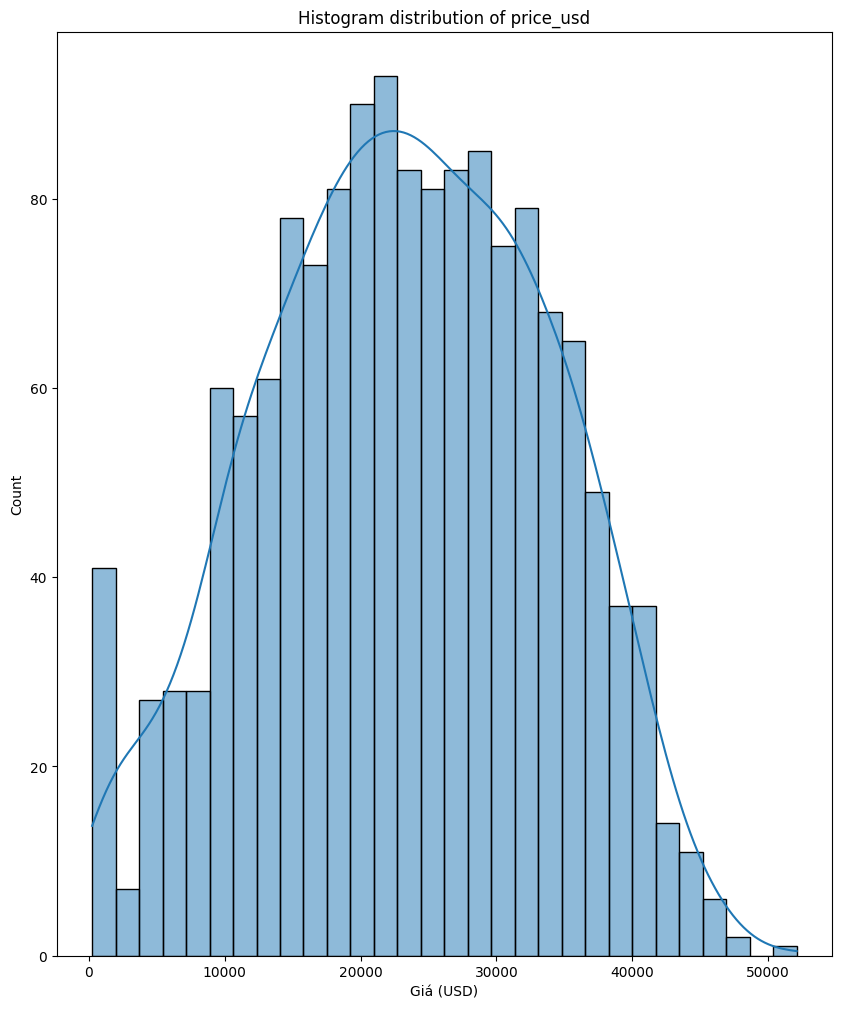

In [65]:
plt.figure(figsize=(10,12))

sns.histplot(
    data = df,
    x ='price_usd',
    kde= True,
    bins = 30,
)
plt.title('Histogram distribution of price_usd')
plt.xlabel('Giá (USD)')
plt.show()

In [66]:
print(df['brand'].value_counts)

<bound method IndexOpsMixin.value_counts of 0          Ford
1           Kia
2         Mazda
3       Hyundai
4         Honda
         ...   
1495    Hyundai
1496    Hyundai
1497        BMW
1498       Ford
1499     Nissan
Name: brand, Length: 1500, dtype: object>


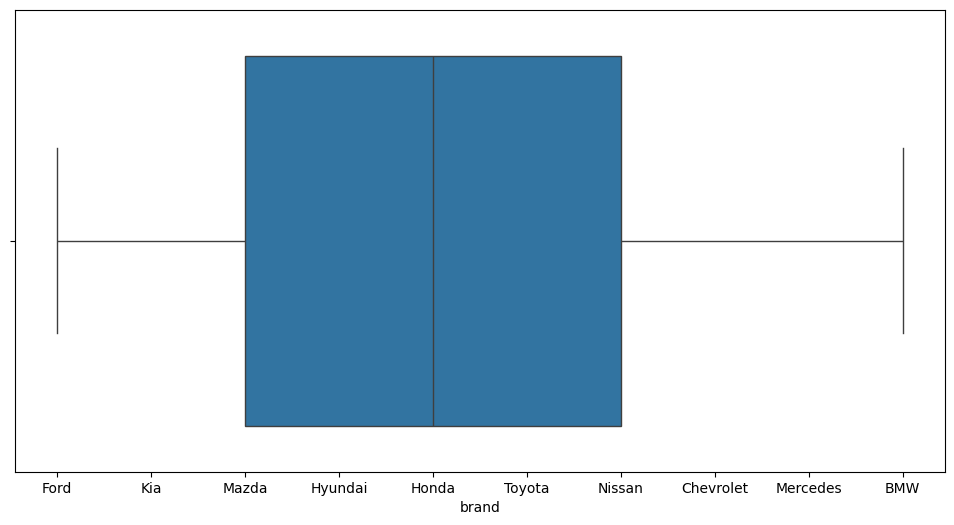

In [67]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data = df,
    x = 'brand'
)
plt.show()

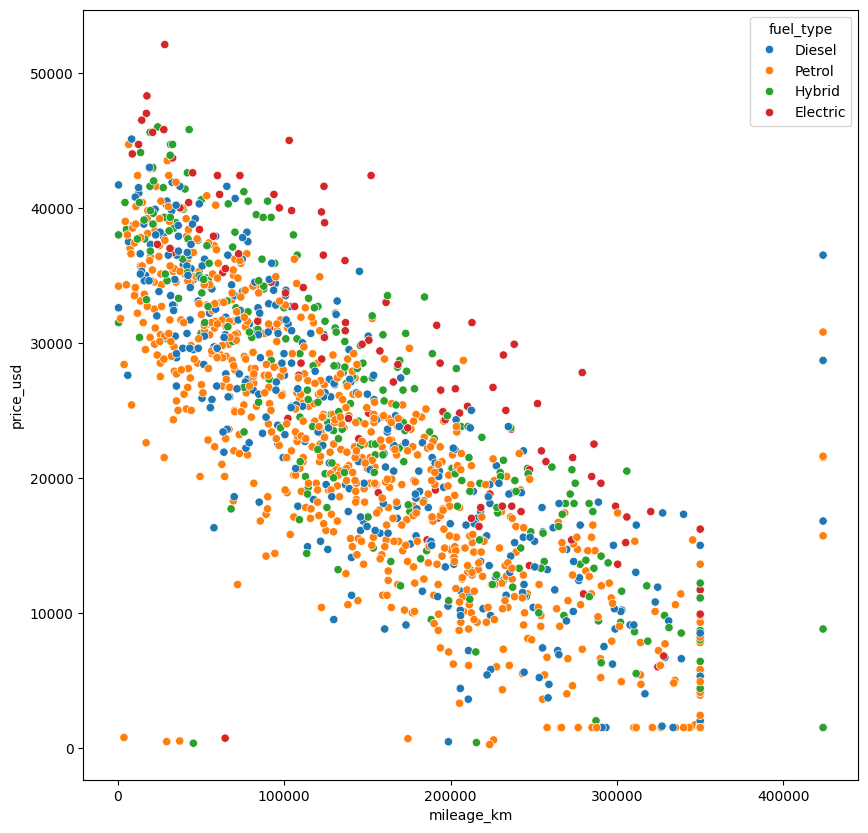

In [68]:
plt.figure(figsize=(10,10))
sns.scatterplot(
    data = df,
    x = "mileage_km",
    y = "price_usd",
    hue = "fuel_type"
)
plt.show()

In [69]:
print("=" * 60)
print("PREPROCESSING")
print("=" * 60)

PREPROCESSING


In [104]:
outlier_indices = df[(df['mileage_km'] > 400000) | (df['price_usd'] < 1000)].index
print(f"Delete {len(outlier_indices)} rows")
df = df.drop(outlier_indices).reset_index(drop=True)

Delete 0 rows


In [71]:
print(df['service_history'].value_counts())

service_history
Full       641
Partial    532
Name: count, dtype: int64


In [105]:
df['service_history'] = df['service_history'].fillna("Full")
df['mileage_km'] = df['mileage_km'].fillna(df['mileage_km'].median())
df['engine_size_L'] = df['engine_size_L'].fillna(df.groupby('brand')['engine_size_L'].transform('median'))

In [106]:
df['car_age'] = 2026 - df['model_year']
df['mileage_per_year'] = df['mileage_km'] / (df['car_age'] + 1)

In [ ]:
print("Encoding categorical columns...")

# Bước A: OneHot cho 'brand'
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder.fit_transform(df[['brand']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['brand']))

df_merged = pd.concat([df.drop('brand', axis=1), encoded_df], axis=1)

cols_to_encode = ['fuel_type', 'transmission', 'service_history']
df_final = pd.get_dummies(
    df_merged, 
    columns=cols_to_encode, 
    drop_first=True,   
    prefix=cols_to_encode 
)

print(f"Số lượng giá trị Null trong df_final: {df_final.isnull().sum().sum()}")

Encoding categorical columns...
Số lượng giá trị Null trong df_final: 0


In [108]:
print("=" * 60)
print("TRAINING")
print("=" * 60)

TRAINING


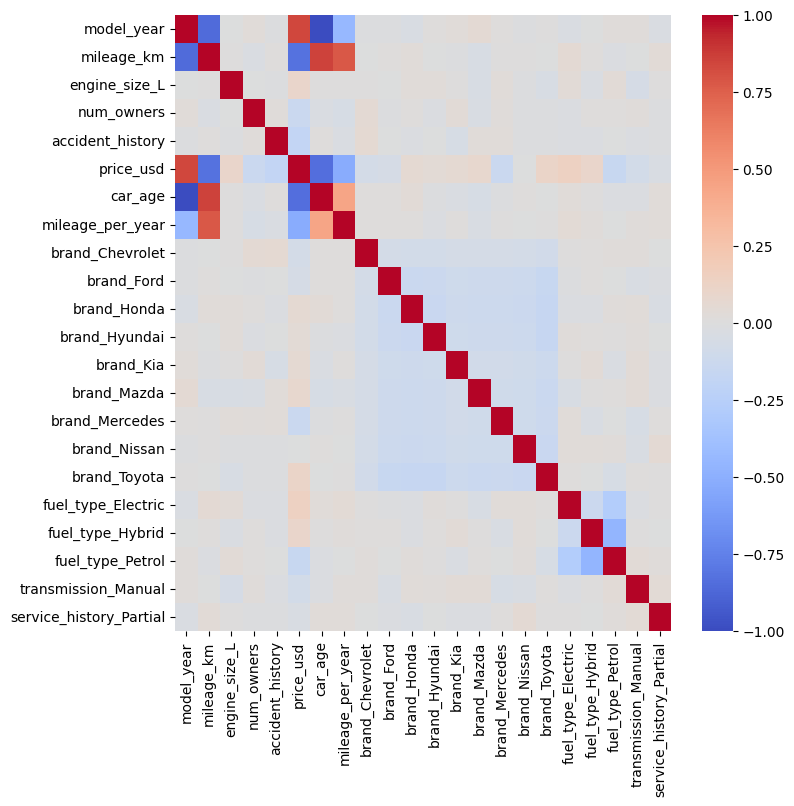

In [109]:
plt.figure(figsize=(8, 8))
sns.heatmap(df_final.corr(numeric_only=True), cmap='coolwarm') # car age va km co ve da cong tuyen, giu 1 cot
plt.show()

In [119]:
features = [
    'car_age', 'mileage_km', 'mileage_per_year', 
    # 'engine_size_L', 'num_owners', 'accident_history',
    # 'brand_Chevrolet', 'brand_Ford', 'brand_Honda', 
    # 'brand_Hyundai', 'brand_Kia', 'brand_Mazda', 
    # 'brand_Mercedes', 'brand_Nissan', 'brand_Toyota'
]

X = df_final[features]

y = df_final['price_usd']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [121]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaler, y_train)

LinearRegression()

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

y_train_pred = model.predict(X_train_scaler)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"{'Metric':<20}{'Train':>20}{'Test':>10}")
print("-" * 42)
print(f"{'MSE':<20}{mse_test:>10.4f}{mse_test:>10.4f}")
print(f"{'RMSE':<20}{np.sqrt(mse_train):>10.4f}{rmse_test:>10.4f}")
print(f"{'R²':<20}{r2_train:>10.4f}{r2_test:>10.4f}")

Metric                             Train      Test
------------------------------------------
MSE                 25445652.470425445652.4704
RMSE                 5088.5776 5044.3684
R²                      0.7499    0.7624


C:\Users\lequa\AppData\Local\Temp\ipykernel_18620\1603782189.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, ax=axes[2], palette='viridis')


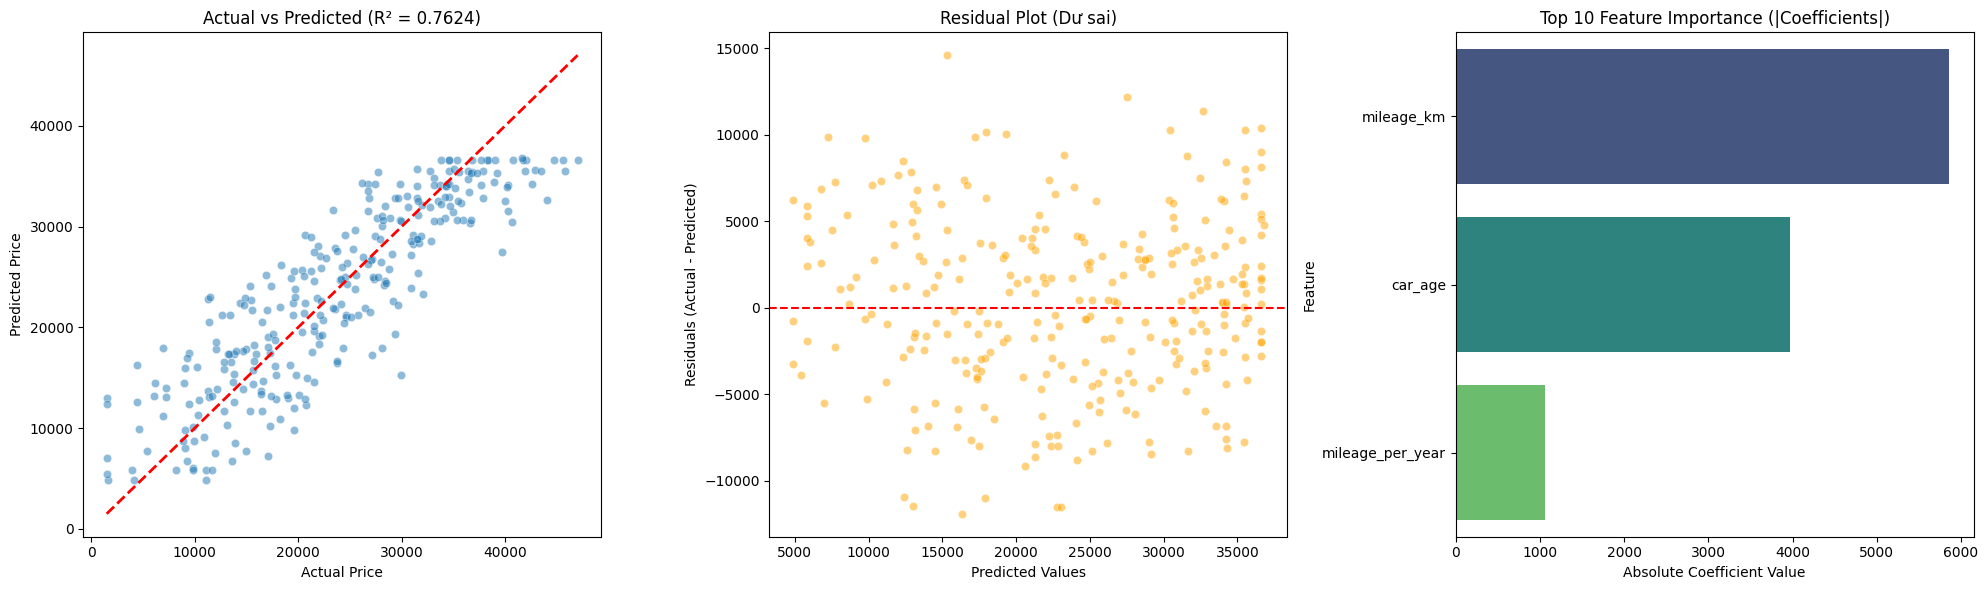

In [ ]:
y_pred = model.predict(X_test_scaled)
residuals = y_test - y_pred


coeffs = model.coef_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(coeffs)
}).sort_values(by='Importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted (R² = {r2_test:.4f})')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], color='orange', alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residual Plot (Dư sai)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

sns.barplot(x='Importance', y='Feature', data=feature_importance, ax=axes[2], palette='viridis')
axes[2].set_title('Top 10 Feature Importance (|Coefficients|)')
axes[2].set_xlabel('Absolute Coefficient Value')

plt.tight_layout()
plt.show()